### Part 3: NLP and Sequence Modeling Mini Project

#### Task 1: Dataset Understanding

In [2]:
import pandas as pd

df = pd.read_csv("customer_support_text_classification.csv")
print(df.head())

  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ticket_id         1500 non-null   str  
 1   channel           1500 non-null   str  
 2   customer_message  1500 non-null   str  
 3   sentiment_label   1500 non-null   str  
 4   word_count        1500 non-null   int64
 5   urgent_flag       1500 non-null   int64
dtypes: int64(2), str(4)
memory usage: 70.4 KB
None


In [4]:
print("Total Records:", len(df))

Total Records: 1500


In [5]:
print(df['sentiment_label'].unique())

<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str


In [6]:
print(df["sentiment_label"].value_counts())

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


In [9]:
import os
os.makedirs("results", exist_ok=True)

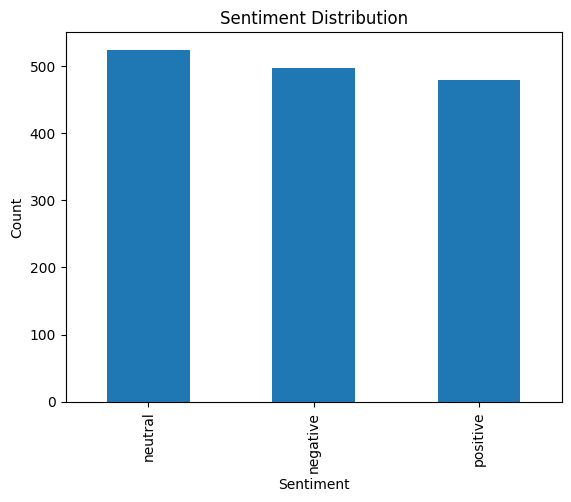

In [10]:
import matplotlib.pyplot as plt



df['sentiment_label'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")
plt.savefig("results/sentiment_distribution.png")
plt.show()

In [11]:
print(df['customer_message'].head())

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: str


In [12]:
print(df["word_count"].mean())

12.722666666666667


In [13]:
df['word_count'] = df['customer_message'].apply(
    lambda x: len(str(x).split())
)

print("Average Word Count:",
      df['word_count'].mean())

Average Word Count: 12.722666666666667


#### Task 2: Text Preprocessing

In [20]:
import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\balaj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\balaj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\balaj\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [17]:
stop_words = set(stopwords.words('english'))

In [18]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens
              if word not in stop_words]

    # Join words back
    return " ".join(tokens)

In [21]:
df['clean_text'] = df['customer_message'].apply(
    preprocess_text
)

print(df[['customer_message',
          'clean_text']].head())

                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                          clean_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  


#### Task 3: Text Vectorization

Why Text Must Be Converted into Numerical Form

Machine learning algorithms cannot understand raw text directly.

Models only work with numerical values.

Text vectorization converts words into numbers.

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)

X_bow = bow.fit_transform(df['clean_text'])

print(X_bow.shape)

(1500, 146)


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['clean_text'])

print(X_tfidf.shape)

(1500, 146)


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(
    df['clean_text']
)


In [26]:
padded_sequences = pad_sequences(
    sequences,
    maxlen=100,
    padding='post',
    truncating='post'
)

print(padded_sequences.shape)

(1500, 100)


#### Task 4: Baseline Model

In [27]:
X = X_tfidf

y = df['sentiment_label']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
y_pred = model.predict(X_test)

Accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



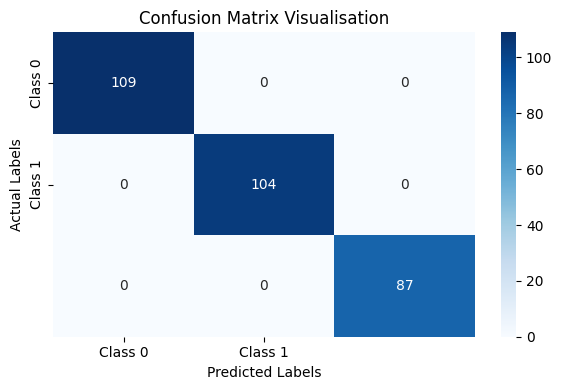

<Figure size 640x480 with 0 Axes>

In [35]:
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'], # Change labels to match your dataset
            yticklabels=['Class 0', 'Class 1'])

plt.title('Confusion Matrix Visualisation')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.tight_layout()
plt.show()
plt.savefig("results/model_evalution.png")

#### Task 5: Sequence Model using LSTM

LSTM Architecture

Customer Message
 
        ↓
Text Cleaning
 
        ↓
Tokenizer
 
        ↓
Integer Sequences

       ↓
Padding

        ↓
Embedding Layer

        ↓
LSTM Layer

        ↓
Dense Output Layer

        ↓
Sentiment Prediction

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=100
    )
)

# LSTM Layer
model.add(LSTM(64))

# Output Layer
model.add(Dense(3, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\balaj\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### Task 6: Attention and Transformer Reflection

1. Why RNNs Struggle with Long-Term Dependencies

RNNs process text sequentially.

Problems:

earlier information fades over time
vanishing gradient problem
difficult to remember long sequences

Example:

"The customer who contacted support last week is still unhappy."

The model may forget important earlier words.

2. How LSTMs Help

LSTMs introduce:

memory cells
forget gates
input gates
output gates

These mechanisms help retain important information longer.

Advantages:

better memory
improved sequence learning
reduced vanishing gradient issue

3. What Attention Solves

Attention allows the model to focus on important words in a sentence.

Instead of compressing everything into one hidden state, attention dynamically selects relevant parts.

Example:

"The product arrived late and it was damaged."

Attention helps identify important words like:

late
damaged

4. Why Transformers are Important

Transformers:

process words in parallel
use self-attention
capture long-range relationships efficiently
train faster than RNNs

Modern Generative AI models such as:

OpenAI GPT
Google BERT
Meta LLaMA

are based on transformer architecture.